# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__Wind Turbines__

## Selected Problem Statement: 
__A private equity firm focused on renewable energy aims to acquire U.S. wind farms but requires deeper insight into the specific structural characteristics and geographic locations that drive peak energy efficiency. To guide these acquisitions, the Investment Committee must evaluate historical Net Generation (MWh) data across various Census Regions, segmented by turbine specifications and technical details. By spotting niche opportunities, distinguishing the physical configurations and regions with the strongest historical performance, the firm can strategically target assets that meet proven benchmarks for high energy output.__

## 1. Introduction & Objectives

### 1.1 Context & Background
Wind energy is a major and growing source of renewable electricity in the U.S., with tens 
of thousands of turbines installed nationwide. Private equity firms often invest in wind 
farms, but returns depend heavily on location — specifically, turbine size, local wind 
strength, and electricity prices. This project analyzes wind turbines across the four U.S. 
Census Regions to find the best region for a new wind farm investment.
### 1.2 Core Analytical Objectives
* Which Census Region has the most installed wind capacity?
* Which region has the strongest wind speed?
* Is there a trade-off between wind speed and electricity rate by region?
* Overall, which region is the best target for new wind farm investment?
---

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [48]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import missingno as msno


In [49]:
# Load data using strictly relative file paths
wind_turbines=pd.read_csv('../Data/wind-turbines.csv', encoding='latin-1')
wind_speed = pd.read_csv('../Data/extra/windiest-states-in-the-us.-2025.csv')
rates = pd.read_csv('../Data/extra/average_electricity_rates.csv')
bills = pd.read_csv('../Data/extra/average_electricity_bills.csv')

# create a working copy so the original stays untouched as a reference
wt_copy = wind_turbines.copy()

---
## 3. Data Handling


### 3.1 get the number of features and records, missing values and data types

In [50]:
wind_turbines.info()

<class 'pandas.DataFrame'>
RangeIndex: 70808 entries, 0 to 70807
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_id        70808 non-null  int64  
 1   faa_ors        65016 non-null  str    
 2   faa_asn        65686 non-null  str    
 3   usgs_pr_id     38263 non-null  float64
 4   eia_id         65015 non-null  float64
 5   t_state        70808 non-null  str    
 6   t_county       70808 non-null  str    
 7   t_fips         70808 non-null  int64  
 8   p_name         70808 non-null  str    
 9   p_year         70195 non-null  float64
 10  p_tnum         70808 non-null  int64  
 11  p_cap          66326 non-null  float64
 12  t_manu         65168 non-null  str    
 13  t_model        65031 non-null  str    
 14  t_cap          65328 non-null  float64
 15  t_hh           64628 non-null  float64
 16  t_rd           64874 non-null  float64
 17  t_rsa          64874 non-null  float64
 18  t_ttlh         64

### 3.2 Examine the sum of missing values in each column.

In [51]:
wind_turbines.isnull().sum().sort_values(ascending=False)


retrofit_year    64822
usgs_pr_id       32545
t_img_date        8316
t_hh              6180
t_ttlh            6180
t_rd              5934
t_rsa             5934
eia_id            5793
faa_ors           5792
t_model           5777
t_manu            5640
t_cap             5480
faa_asn           5122
p_cap             4482
p_year             613
t_state              0
case_id              0
t_fips               0
t_county             0
p_tnum               0
p_name               0
t_conf_atr           0
retrofit             0
t_conf_loc           0
t_img_srce           0
xlong                0
ylat                 0
dtype: int64

### 3.3 preview the first 5 rows of the data.

In [52]:
wind_turbines.head()

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644
3,3063272,19-028134,2014-WTE-4084-OE,NaN,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,4/24/2017,Digital Globe,-93.430367,42.028233
4,3053390,19-028015,2015-WTE-6386-OE,NaN,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,6/1/2017,Digital Globe,-93.700424,41.977608


In [53]:
# check duplicate rows (entire row)
wind_turbines.duplicated().sum()

np.int64(0)

In [54]:
wind_turbines['case_id'].duplicated().sum()


np.int64(0)

### 3.4 Define function to map states to Census Regions

In [55]:
def get_census_region(state_code):
    northeast = ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'PA', 'NJ']
    midwest = ['WI', 'MI', 'IL', 'IN', 'OH', 'ND', 'SD', 'NE', 'KS', 'MN', 'IA', 'MO']
    south = ['DE', 'MD', 'VA', 'WV', 'KY', 'NC', 'SC', 'GA', 'FL', 'AL', 'TN', 'MS', 'AR', 'LA', 'OK', 'TX']
    west = ['ID', 'MT', 'WY', 'NV', 'UT', 'CO', 'AZ', 'NM', 'WA', 'OR', 'CA', 'AK', 'HI']
    
    if state_code in northeast:
        return 'Northeast'
    elif state_code in midwest:
        return 'Midwest'
    elif state_code in south:
        return 'South'
    elif state_code in west:
        return 'West'
    else:
        return 'Other'

# create census_region column and t_cap_mw column by using .apply()
wt_copy['census_region'] = wt_copy['t_state'].apply(get_census_region)
wt_copy['t_cap_mw'] = wt_copy['t_cap'] / 1000.0
wt_copy.head(3)

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat,census_region,t_cap_mw
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908,West,0.095
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435,West,0.095
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644,West,0.095


### 3.5 Check wind_speed , rates, bills dataset 

In [56]:
wind_speed.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   stateFlagCode                      0 non-null      float64
 1   state                              50 non-null     str    
 2   WindiestStatesAverageWindSpeedMPH  50 non-null     float64
 3   MeanWindSpeed328ft                 50 non-null     float64
 4   MeanWindPower328ft                 50 non-null     int64  
 5   MeanWindSpeed33ft                  50 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.9 KB


In [57]:
wind_speed.isnull().sum()


stateFlagCode                        50
state                                 0
WindiestStatesAverageWindSpeedMPH     0
MeanWindSpeed328ft                    0
MeanWindPower328ft                    0
MeanWindSpeed33ft                     0
dtype: int64

In [58]:
wind_speed.head()


,stateFlagCode,state,WindiestStatesAverageWindSpeedMPH,MeanWindSpeed328ft,MeanWindPower328ft,MeanWindSpeed33ft
0,NaN,South Dakota,21.32,20.3,722,12.8
1,NaN,Montana,21.03,20.5,985,13.5
2,NaN,Wyoming,20.88,21.5,964,14.1
3,NaN,Idaho,20.59,16.5,472,10.6
4,NaN,Colorado,20.16,20.0,751,12.8


In [59]:
wind_speed.duplicated().sum()


np.int64(0)

In [60]:
# drop stateFlagCode - entirely empty, no analytical value
wind_speed = wind_speed.drop(columns=['stateFlagCode'])

In [61]:
rates.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   State        51 non-null     str    
 1   Residential  51 non-null     float64
 2   Commercial   51 non-null     float64
 3   Average      51 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.2 KB


In [62]:
rates.isnull().sum()

State          0
Residential    0
Commercial     0
Average        0
dtype: int64

In [63]:
rates.head()

,State,Residential,Commercial,Average
0,Alabama,14.91,13.83,14.37
1,Alaska,22.38,18.43,20.41
2,Arizona,15.20,11.92,13.56
3,Arkansas,11.74,10.11,10.93
4,California,30.55,23.13,26.84


In [64]:
rates.duplicated().sum()

np.int64(0)

In [65]:
bills.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   State        50 non-null     str    
 1   Residential  50 non-null     float64
 2   Commercial   50 non-null     str    
 3   Average      50 non-null     str    
dtypes: float64(1), str(3)
memory usage: 2.7 KB


In [66]:
bills.isnull().sum()

State          0
Residential    0
Commercial     0
Average        0
dtype: int64

In [67]:
bills.head(15)


,State,Residential,Commercial,Average
0,Alabama,115.00,679.26,397.13
1,Alaska,198.10,"1,201.93",700.02
2,Arizona,118.76,645.96,382.36
3,Arkansas,101.92,577.55,339.74
4,California,258.38,"1,400.90",829.64
5,Colorado,122.52,670.78,396.65
6,Connecticut,223.50,"1,194.65",709.07
7,Delaware,124.49,662.19,393.34
8,Florida,126.37,704.03,415.2
9,Georgia,116.88,659.27,388.07


In [68]:
# fix comma-separated numbers in Commercial and Average columns before converting to numeric
for col in ['Commercial', 'Average']:
    bills[col] = bills[col].astype(str).str.replace(',', '', regex=False)
    bills[col] = pd.to_numeric(bills[col], errors='coerce')

# confirm the fix worked - dtypes should now all be float64
bills.dtypes

State              str
Residential    float64
Commercial     float64
Average        float64
dtype: object

In [69]:
# wind_speed/elec_rates/elec_bills use full state names, wt_copy uses 2-letter abbreviations (t_state)

us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
    'Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'}

wind_speed['state'] = wind_speed['state'].str.strip().map(us_state_abbrev)
rates['State'] = rates['State'].str.strip().map(us_state_abbrev)
bills['State'] = bills['State'].str.strip().map(us_state_abbrev)


In [70]:
# Build clean subsets with clear column names

wind_speed_clean = wind_speed[['state', 'WindiestStatesAverageWindSpeedMPH', 'MeanWindSpeed328ft', 'MeanWindPower328ft', 'MeanWindSpeed33ft']].rename(
    columns={'WindiestStatesAverageWindSpeedMPH': 'avg_wind_speed_mph',
             'MeanWindSpeed328ft': 'wind_speed_328ft',
             'MeanWindPower328ft': 'wind_power_328ft',
             'MeanWindSpeed33ft': 'wind_speed_33ft'}
)

rates_clean = rates[['State', 'Residential', 'Commercial', 'Average']].rename(
    columns={'Residential': 'rate_residential', 'Commercial': 'rate_commercial', 'Average': 'rate_average'}
)

bills_clean = bills[['State', 'Residential', 'Commercial', 'Average']].rename(
    columns={'Residential': 'bill_residential', 'Commercial': 'bill_commercial', 'Average': 'bill_average'}
)

In [71]:
# Merge everything onto wt_copy

wt_copy = pd.merge(left=wt_copy, right=wind_speed_clean, left_on='t_state',right_on='state',  how='left')
wt_copy = pd.merge(left=wt_copy, right=rates_clean, left_on='t_state',right_on='State',  how='left')
wt_copy = pd.merge(left=wt_copy, right=bills_clean, left_on='t_state',right_on='State',  how='left')
wt_copy.head(3)

,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,wind_power_328ft,wind_speed_33ft,State_x,rate_residential,rate_commercial,rate_average,State_y,bill_residential,bill_commercial,bill_average
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,649.0,10.7,CA,30.55,23.13,26.84,CA,258.38,1400.9,829.64
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,649.0,10.7,CA,30.55,23.13,26.84,CA,258.38,1400.9,829.64
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,649.0,10.7,CA,30.55,23.13,26.84,CA,258.38,1400.9,829.64


In [72]:
# Drop territories not covered by census regions (PR, GU)

wt_copy = wt_copy[~wt_copy['t_state'].isin(['PR', 'GU'])]

In [73]:
# Merge validation
wt_copy.isnull().sum()



case_id                   0
faa_ors                5728
faa_asn                5107
usgs_pr_id            32481
eia_id                 5789
t_state                   0
t_county                  0
t_fips                    0
p_name                    0
p_year                  611
p_tnum                    0
p_cap                  4481
t_manu                 5637
t_model                5774
t_cap                  5479
t_hh                   6179
t_rd                   5933
t_rsa                  5933
t_ttlh                 6179
retrofit                  0
retrofit_year         64758
t_conf_atr                0
t_conf_loc                0
t_img_date             8316
t_img_srce                0
xlong                     0
ylat                      0
census_region             0
t_cap_mw               5479
state                     0
avg_wind_speed_mph        0
wind_speed_328ft          0
wind_power_328ft          0
wind_speed_33ft           0
State_x                   0
rate_residential    

In [74]:
#drop duplicated columns after merging)
wt_copy = wt_copy.drop(columns=['state', 'State_x', 'State_y' ], errors='ignore')


In [75]:
wt_copy.duplicated().sum()

np.int64(0)

In [76]:
wt_copy['census_region'].value_counts()


census_region
Midwest      26716
South        22962
West         18416
Northeast     2650
Name: count, dtype: int64

In [77]:
# show ALL unique manufacturer names with counts

pd.set_option('display.max_rows', None)
print(wt_copy['t_manu'].value_counts())
pd.reset_option('display.max_rows')

t_manu
GE Wind                                                                     29137
Vestas                                                                      16246
Siemens                                                                      4991
Gamesa                                                                       3077
Mitsubishi                                                                   2620
Siemens Gamesa Renewable Energy                                              2043
Nordex                                                                       1591
Suzlon                                                                       1316
Acciona                                                                       758
REpower                                                                       574
NEG Micon                                                                     529
Enron                                                                         396
Bonus    

In [78]:
map_manu = {
    'Gamesa': 'Siemens',
    'Siemens Gamesa Renewable Energy': 'Siemens',
    'Goldwind Americas': 'Goldwind'
}
wt_copy['t_manu'] = wt_copy['t_manu'].str.strip().replace(map_manu)

In [79]:
key_cols = ['t_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh', 'p_cap']
missing_pct = (wt_copy[key_cols].isnull().mean() * 100).round(2)
print(missing_pct)

t_cap     7.74
t_hh      8.73
t_rd      8.39
t_rsa     8.39
t_ttlh    8.73
p_cap     6.33
dtype: float64


<Axes: >

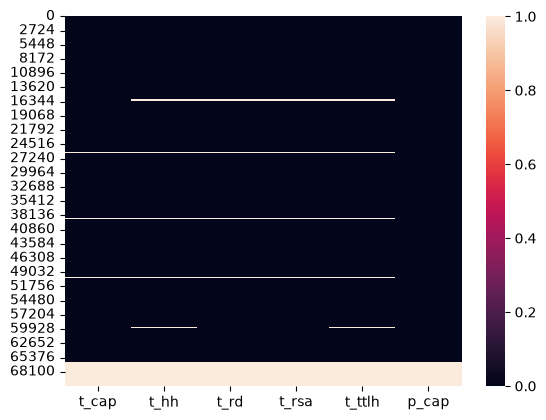

In [80]:
sns.heatmap(wind_turbines[key_cols].isnull())

Text(0.5, 1.0, 'Correlation of Missingness Between Columns')

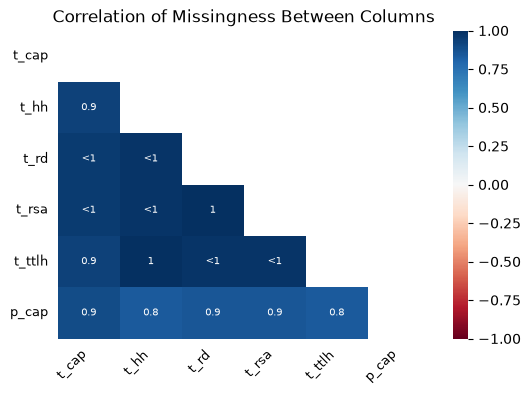

In [81]:
msno.heatmap(wind_turbines[key_cols], figsize=(6,4), fontsize= 9)
plt.title('Correlation of Missingness Between Columns')

In [82]:
# drop rows missing key physical spec columns (t_cap, t_hh, t_rd, t_rsa, t_ttlh, p_cap)
# these values can't be reliably estimated/imputed since they represent actual physical 
# turbine specs, and missing rows are a small % of the data (<9% per column, <1.1% after 
# removing fully-empty rows), so dropping them has minimal impact on the analysis

wt_copy = wt_copy.dropna(subset=key_cols)
wt_copy[key_cols].isnull().sum()


t_cap     0
t_hh      0
t_rd      0
t_rsa     0
t_ttlh    0
p_cap     0
dtype: int64

In [83]:
# save the final cleaned dataset 
wt_copy.to_csv('../Data/wind_turbines_clean.csv', index=False)


---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1 Aggregating Key Metrics by Census Region

In [84]:
region_summary = wt_copy.groupby('census_region').agg(
    total_turbines=('case_id', 'count'),
    total_capacity_mw=('t_cap_mw', 'sum'),
    avg_capacity_mw=('t_cap_mw', 'mean'),
    avg_hub_height=('t_hh', 'mean'),
    avg_rotor_diameter=('t_rd', 'mean'),
    avg_wind_speed=('avg_wind_speed_mph', 'mean'),
    avg_electricity_rate=('rate_average', 'mean'),
    avg_electricity_bill=('bill_average', 'mean')
).reset_index()

region_summary

,census_region,total_turbines,total_capacity_mw,avg_capacity_mw,avg_hub_height,avg_rotor_diameter,avg_wind_speed,avg_electricity_rate,avg_electricity_bill
0,Midwest,25063,50090.010,1.998564,84.092040,98.632614,18.539400,12.091133,366.885281
1,Northeast,2592,5109.550,1.971277,83.064275,88.021836,16.436370,19.893530,564.739699
2,South,21838,45537.739,2.085252,82.228899,100.339097,15.825460,11.687686,331.774463
3,West,15069,27242.790,1.807870,73.982992,86.440268,17.126513,15.849151,480.039272


### 4.2 Ranking Regions by Wind Speed and Electricity Rate

In [85]:
# sort by wind speed to see ranking
region_summary.sort_values('avg_wind_speed', ascending=False)[['census_region', 'avg_wind_speed']]

,census_region,avg_wind_speed
0,Midwest,18.539400
3,West,17.126513
1,Northeast,16.436370
2,South,15.825460


In [86]:
# sort by electricity rate to see ranking
region_summary.sort_values('avg_electricity_rate', ascending=False)[['census_region', 'avg_electricity_rate']]

,census_region,avg_electricity_rate
1,Northeast,19.893530
3,West,15.849151
0,Midwest,12.091133
2,South,11.687686


### 4.3. Key Visualizations

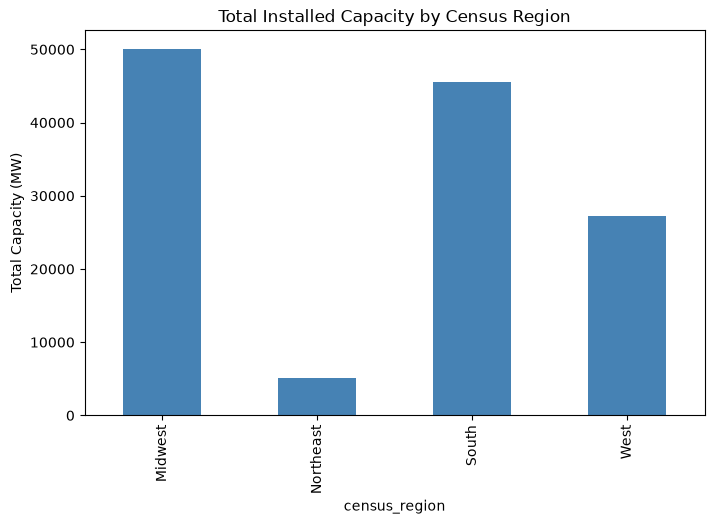

In [89]:
# Visualization 1: Total Installed Capacity by Census Region

region_summary.plot(x='census_region',
                    y='total_capacity_mw',
                    kind='bar', figsize=(8,5), legend=False, color='steelblue' ,
                    title= 'Total Installed Capacity by Census Region',
                   ylabel='Total Capacity (MW)')

plt.savefig('../Presentation/images/viz1_total_capacity.png', dpi=150, bbox_inches='tight')

plt.show()

**Visualization 1 Interpretation:**
> This chart shows the Midwest has the largest total installed wind capacity (~50,100 MW), 
> closely followed by the South (~45,500 MW). The Northeast has by far the smallest footprint 
> (~5,100 MW), while the West falls in the middle (~27,400 MW).

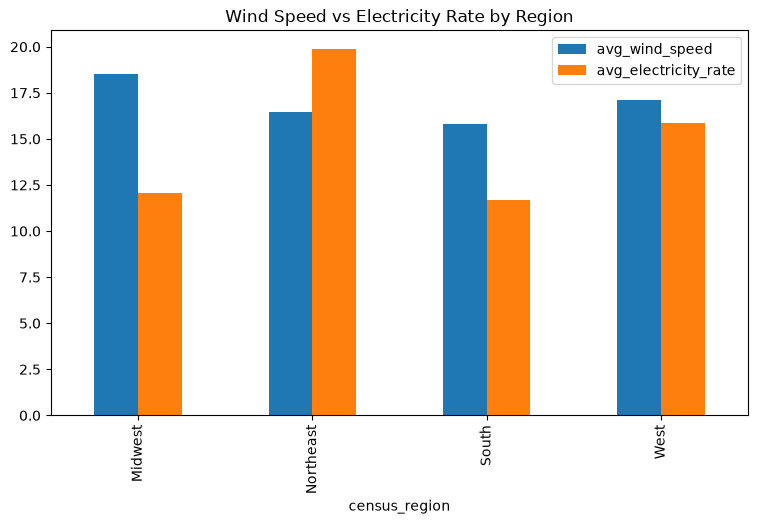

In [90]:
# Visualization 2: Wind Speed vs Electricity Rate by Region

region_summary.plot(x='census_region', y=['avg_wind_speed', 'avg_electricity_rate'], kind='bar', figsize=(9,5), title='Wind Speed vs Electricity Rate by Region')

plt.savefig('../Presentation/images/viz2_wind_vs_rate.png', dpi=150, bbox_inches='tight')

plt.show()

**Visualization 2 Interpretation:**
 > This chart shows a trade-off: the Midwest has the strongest wind but a lower electricity 
> rate, while the Northeast has the highest rate but the weakest wind. So the best region 
> depends on balancing both wind speed and electricity price together, not just one factor.

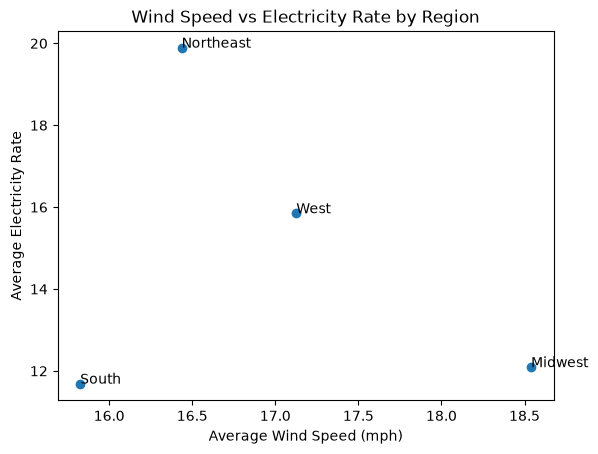

In [91]:
# Visualization 3: Wind Speed vs Electricity Rate (Combined View)
plt.scatter(region_summary['avg_wind_speed'], region_summary['avg_electricity_rate'])

# add region name next to each point
for i, row in region_summary.iterrows():
    plt.text(row['avg_wind_speed'], row['avg_electricity_rate'], row['census_region'])

plt.xlabel('Average Wind Speed (mph)')
plt.ylabel('Average Electricity Rate')
plt.title('Wind Speed vs Electricity Rate by Region')

plt.savefig('../Presentation/images/viz3_scatter.png', dpi=150, bbox_inches='tight')

plt.show()

**Visualization 3 Interpretation:**
> This scatter plot combines wind speed and electricity rate into a single view.
>  The Midwest sits far right (strong wind) but low (cheap electricity),
> while the Northeast sits high (expensive electricity) but left (weak wind) — visually confirming the trade-off between 
> the two factors.

#### ---
## 5. Summary of Findings & Actionable Recommendations

### 5.1 Key Insights (Summary of Findings)
*  The Midwest has the most installed wind capacity (~50,100 MW) and the strongest average 
  wind speed (18.6 mph) of any region.
*  Stronger wind doesn't always mean higher electricity prices — the Midwest has great wind but 
  a below-average rate (12.1 cents/kWh), while the Northeast has the highest rate (19.9 
  cents/kWh) but the weakest wind and only 2,650 turbines.
*  The South has the second-most installed capacity and the largest average turbine size, but 
  currently has the lowest electricity rate and below-average wind speed.
*  The West ranks second in both wind speed and electricity rate, but has the smallest average 
  turbine size of any region.

### 5.2 Actionable Recommendations
* Prioritize the Midwest for new wind farm investment — it combines the strongest wind 
  resource with an already large, established market.
* Consider the Northeast as a smaller, secondary opportunity, since its high electricity 
  prices could offset its weaker wind resource for a smaller-scale project.
* Deprioritize the South and West for new investment based on current wind speed and 
  electricity rate data, though the South's existing infrastructure may still support 
  expansion of current projects.

### 5.3 Limitations & Areas for Further Research
* Actual energy production data (Net Generation in MWh) was not available, so installed 
  turbine capacity was used as a stand-in measure.
* Electricity rates used are retail/consumer prices, not necessarily the wholesale price a 
  wind farm would actually be paid for its electricity.
* This analysis compared whole Census Regions — looking at individual states could reveal 
  more specific and precise investment locations.
---

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| column_name_1 | type | Original / Engineered | Detailed explanation of what this variable represents |
| column_name_2 | type | Original / Engineered | Detailed explanation of what this variable represents |

### 6.2 References & Sources
* *Source 1:*